In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
import pandas as pd
from itertools import combinations
import copy
import random

In [ ]:
# CIFAR10_PATH is where the CIFAR10 data batches are downloaded directly
CIFAR10_PATH = "res/train"
# NOISY_PATH has your noisy copies that you created and formatted according to the original CIFAR-10 batch pickle format
NOISY_PATH = "res/test"

In [4]:
def unpickle(file):
    import pickle
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict

In [5]:
def load_batch(path):
    '''Load a batch of the data,
    which corresponds to one pickle file'''
    with open(path, 'rb') as f:
        d = pickle.load(f, encoding='bytes')
    images = d[b'data'].reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
    labels = np.array(d[b'labels'])
    return images, labels

def load_label_names():
    '''Load the label text names
    for human readability.'''
    return ['airplane','automobile','bird','cat','deer',
            'dog','frog','horse','ship','truck']

In [6]:
def repickle(file_path, data_structure):
    with open(file_path, 'wb') as file:
        pickle.dump(data_structure, file)

In [7]:

def preprocess_images(images):
    '''
    Take in numpy array of images.  Normalize pixel values,
    flatten, scale and return
    '''
    print(images.shape)
    images.astype(np.float32) / 255.0
    flat = images.reshape(len(images), -1)
    print(flat.shape)
    scaler = unpickle('scaler.pkl')
    flat = scaler.transform(flat)
    return flat

In [8]:
# Mapping dictionary
label_codes = {
    0: 'aircraft',
    1: 'car',
    2: 'bird',
    3: 'cat',
    4: 'deer',
    5: 'dog',
    6: 'frog',
    7: 'horse',
    8: 'ship',
    9: 'truck'
}

In [9]:
def get_OvO_pairs_list(model, label_codes_dict):
    total = 0
    class_pairs = list(combinations(model.classes_, 2))
    for k, (class_a, class_b) in enumerate(class_pairs):
        print(f'Model: {k} compares classes: {class_a}, {label_codes_dict.get(class_a)} and {class_b}, {label_codes_dict.get(class_b)}')
    for j, estimator in enumerate(model.estimators_):
        print(f'model {j}')
        for i, svs in enumerate(estimator.n_support_):
            print(f"Class {i}: {svs} support vectors")
            total += svs
    #print(f' total support vectors: {total}')
    return class_pairs

In [10]:
def confirm_sv_match(sv_class_dist_dfs, model, pairs):
    for j in range(0, len(sv_class_dist_dfs), 2):
        label1 = model.classes_[pairs[int(j/2)][0]]
        label2 = model.classes_[pairs[int(j/2)][1]]
        
        sv_labels_found = sv_class_dist_dfs[j]['labels'].unique()
        unexpected = [l for l in sv_labels_found if l not in [label1, label2]]
        
        if unexpected:
            print(f"Model {int(j/2)} ({label_codes.get(label1)} vs "
                f"{label_codes.get(label2)}): unexpected labels {unexpected}")

In [11]:
def create_model_folders(class_pairs):
    for k, (class_a, class_b) in enumerate(class_pairs):
        print(f'Model: {k} compares classes: {class_a}, {label_codes.get(class_a)} and {class_b}, {label_codes.get(class_b)}')
        try:
            os.mkdir(path=f'sv_images/models/ovo_model_{k}')
            os.mkdir(path=f'sv_images/models/ovo_model_{k}/class_{str(label_codes.get(class_a))}')
            os.mkdir(path=f'sv_images/models/ovo_model_{k}/class_{str(label_codes.get(class_b))}')
        except FileExistsError:
            print("FileExistsError")
            continue
    

In [22]:
def populate_model_folders(model, labels_list, images_list, pairs, class_pairs_list):
    for j, estimator in enumerate(model.estimators_):
        label1 = model.classes_[pairs[j][0]]
        label2 = model.classes_[pairs[j][1]]
        
        # Reconstruct the binary subset scikit-learn used internally
        global_mask = np.where((labels_list == label1) | (labels_list == label2))[0]
        
        sv_indices_item = estimator.support_  # local indices
        
        for i, n_supports_count in enumerate(estimator.n_support_):
            start_idx = sum(estimator.n_support_[:i])
            end_idx = start_idx + n_supports_count
            
            local_indices = sv_indices_item[start_idx:end_idx]
            
            # Map local -> global before indexing into train_images
            global_indices = global_mask[local_indices]
            sv_images_item = images_list[global_indices]
            # iteratively navigating the support vectors file org system.
            # you need sv_images/models/ovo_model_# to start
            file_path = 'sv_images/models/ovo_model_'+str(j)+'/class_'+str(class_pairs_list[j][i])
            repickle(file_path+'/_indices.pkl', global_indices) # save the indices file in the new folder
            repickle(file_path+'/_images.pkl', sv_images_item) # save the images file in the new folder

In [23]:
def read_sv_images_indices(model, class_pairs_list):
    sv_indices_lists = []
    sv_images_lists = []
    for j, estimator in enumerate(model.estimators_):
        for i, n_supports_count in enumerate(estimator.n_support_):
            file_path = 'sv_images/models/ovo_model_'+str(j)+'/class_'+str(class_pairs_list[j][i])
            sv_indices_lists.append(unpickle(file_path+'/_indices.pkl'))
            sv_images_lists.append(unpickle(file_path+'/_images.pkl'))
    return sv_images_lists, sv_indices_lists

In [ ]:
# If needed, train your model and save for later
"""print("Training OvO...")
#start = time.time()

from sklearn.multiclass import OneVsOneClassifier
from sklearn.svm import SVC

model_ovo = OneVsOneClassifier(SVC(kernel=
                                   'linear'))
model_ovo.fit(X_train_flat, train_labels)
#print("OvO time:", time.time() - start)
pickle.dump(model_ovo, open("model_ovo_wrapper.pkl", "wb")) # saves model
# later can access with model_ovo = pickle.load(open("model_ovo.pkl", "rb"))"""

'print("Training OvO...")\n#start = time.time()\n\nfrom sklearn.multiclass import OneVsOneClassifier\nfrom sklearn.svm import SVC\n\n\nmodel_ovo = OneVsOneClassifier(SVC(kernel=\n                                   \'linear\'))\nmodel_ovo.fit(X_train_flat, train_labels)\n#print("OvO time:", time.time() - start)\npickle.dump(model_ovo, open("model_ovo_wrapper.pkl", "wb")) # saves model\n# later can access with model_ovo = pickle.load(open("model_ovo.pkl", "rb"))'

In [15]:
model_ovo = unpickle('model_ovo_wrapper.pkl')

In [16]:
class_pairs_list = get_OvO_pairs_list(model_ovo, label_codes)
print(class_pairs_list)
print(len(class_pairs_list))

Model: 0 compares classes: 0, aircraft and 1, car
Model: 1 compares classes: 0, aircraft and 2, bird
Model: 2 compares classes: 0, aircraft and 3, cat
Model: 3 compares classes: 0, aircraft and 4, deer
Model: 4 compares classes: 0, aircraft and 5, dog
Model: 5 compares classes: 0, aircraft and 6, frog
Model: 6 compares classes: 0, aircraft and 7, horse
Model: 7 compares classes: 0, aircraft and 8, ship
Model: 8 compares classes: 0, aircraft and 9, truck
Model: 9 compares classes: 1, car and 2, bird
Model: 10 compares classes: 1, car and 3, cat
Model: 11 compares classes: 1, car and 4, deer
Model: 12 compares classes: 1, car and 5, dog
Model: 13 compares classes: 1, car and 6, frog
Model: 14 compares classes: 1, car and 7, horse
Model: 15 compares classes: 1, car and 8, ship
Model: 16 compares classes: 1, car and 9, truck
Model: 17 compares classes: 2, bird and 3, cat
Model: 18 compares classes: 2, bird and 4, deer
Model: 19 compares classes: 2, bird and 5, dog
Model: 20 compares classe

In [17]:
create_model_folders(class_pairs_list)

Model: 0 compares classes: 0, aircraft and 1, car
Model: 1 compares classes: 0, aircraft and 2, bird
Model: 2 compares classes: 0, aircraft and 3, cat
Model: 3 compares classes: 0, aircraft and 4, deer
Model: 4 compares classes: 0, aircraft and 5, dog
Model: 5 compares classes: 0, aircraft and 6, frog
Model: 6 compares classes: 0, aircraft and 7, horse
Model: 7 compares classes: 0, aircraft and 8, ship
Model: 8 compares classes: 0, aircraft and 9, truck
Model: 9 compares classes: 1, car and 2, bird
Model: 10 compares classes: 1, car and 3, cat
Model: 11 compares classes: 1, car and 4, deer
Model: 12 compares classes: 1, car and 5, dog
Model: 13 compares classes: 1, car and 6, frog
Model: 14 compares classes: 1, car and 7, horse
Model: 15 compares classes: 1, car and 8, ship
Model: 16 compares classes: 1, car and 9, truck
Model: 17 compares classes: 2, bird and 3, cat
Model: 18 compares classes: 2, bird and 4, deer
Model: 19 compares classes: 2, bird and 5, dog
Model: 20 compares classe

In [21]:
class_pairs_names = []
for k, (class_a, class_b) in enumerate(class_pairs_list):
    class_pairs_names.append([label_codes.get(class_a), label_codes.get(class_b)])

print(class_pairs_names)

#sv_im_lists, sv_idx_lists = get_sv_images_indices(model_ovo, class_pairs_names)

[['aircraft', 'car'], ['aircraft', 'bird'], ['aircraft', 'cat'], ['aircraft', 'deer'], ['aircraft', 'dog'], ['aircraft', 'frog'], ['aircraft', 'horse'], ['aircraft', 'ship'], ['aircraft', 'truck'], ['car', 'bird'], ['car', 'cat'], ['car', 'deer'], ['car', 'dog'], ['car', 'frog'], ['car', 'horse'], ['car', 'ship'], ['car', 'truck'], ['bird', 'cat'], ['bird', 'deer'], ['bird', 'dog'], ['bird', 'frog'], ['bird', 'horse'], ['bird', 'ship'], ['bird', 'truck'], ['cat', 'deer'], ['cat', 'dog'], ['cat', 'frog'], ['cat', 'horse'], ['cat', 'ship'], ['cat', 'truck'], ['deer', 'dog'], ['deer', 'frog'], ['deer', 'horse'], ['deer', 'ship'], ['deer', 'truck'], ['dog', 'frog'], ['dog', 'horse'], ['dog', 'ship'], ['dog', 'truck'], ['frog', 'horse'], ['frog', 'ship'], ['frog', 'truck'], ['horse', 'ship'], ['horse', 'truck'], ['ship', 'truck']]


In [24]:
# Load ALL training data
train_images = []
train_labels = []

for i in range(1, 6):
    imgs, labs = load_batch(os.path.join(CIFAR10_PATH, f"data_batch_{i}"))
    train_images.append(imgs)
    train_labels.append(labs)

train_images = np.concatenate(train_images)
train_labels = np.concatenate(train_labels)

# Load test data
test_images, test_labels = load_batch(
    os.path.join(NOISY_PATH, 'test_batch_sigma_0_00')
)

# Load label names
label_names = load_label_names()

C:\Users\tdefu\AppData\Local\Temp\ipykernel_11632\1529496855.py:5: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = pickle.load(f, encoding='bytes')


In [25]:
populate_model_folders(model_ovo, load_label_names(), train_images, class_pairs_list, class_pairs_names)


IndexError: index 2 is out of bounds for axis 0 with size 0

90
['ship', 'truck']
44 2


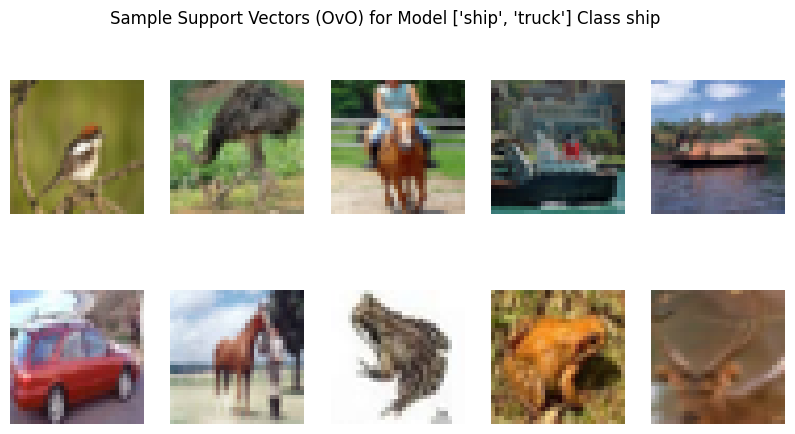

In [ ]:
print(len(sv_im_lists)) # 90
model_idx = 0
class_idx = 0
# Check that the support_vectors one hot column worked
# print(df['support_vectors'][0:20])
# print(sv_indices_list[j][0:20])
if ((class_idx+1) % 2): # this will be true if the current class_idx is divisible by 2 (even) false if odd
    model_name = class_pairs_names.pop() # example: ['ship', 'truck']
print(model_name) 
class_name = model_name[class_idx] # class name example: 'ship' or 'truck'
class_idx = (class_idx + 1) % 2 # increment class idx. Class idx alternates 0 or 1
plt.figure(figsize=(10,5)) # open figure
image_bank = copy.deepcopy(sv_im_lists[0].tolist()) # copy the sv_images_list at index 0
#image_bank_class = image_bank
for i in range(min(10, len(sv_im_lists[0]))): # always range 10, since none of these models had less than 10 support vectors
    plt.subplot(2,5,i+1) # one indexed 1-10
    plt.imshow(image_bank.pop(random.randint(0, len(image_bank)-1))) # show the image from a random image_bank index without replacement
    plt.axis('off') 
try: 
    print(f'{len(class_pairs_names)} {len(class_pairs_names[model_idx])}')
    plt.suptitle(f"Sample Support Vectors (OvO) for Model {model_name} Class {class_name}")
except IndexError:
    print(f"list index out of range for model_idx: {model_idx}, class_idx: {class_idx}")
plt.show()

bird


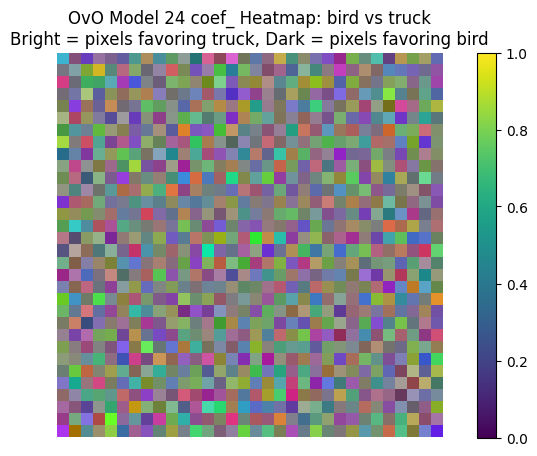

In [63]:
model_idx = 23  # whichever model you want
estimators = model_ovo.estimators_
estimator = estimators[model_idx]
print(class_pairs_names[23][0])
label1 = class_pairs_names[23][0]
label2 = class_pairs_names[23][1]

coef = estimator.coef_[0]        # shape (3072,)
coef_image = coef.reshape(32, 32, 3)

vmax = np.abs(coef_image).max()
coef_norm = (coef_image - coef_image.min()) / (coef_image.max() - coef_image.min())

plt.figure(figsize=(9, 5))
plt.imshow(coef_norm)
plt.axis('off')
plt.title(f'OvO Model {model_idx+1} coef_ Heatmap: {label1} vs {label2}\n'
          f'Bright = pixels favoring {label2}, '
          f'Dark = pixels favoring {label1}')
plt.colorbar()
plt.show()

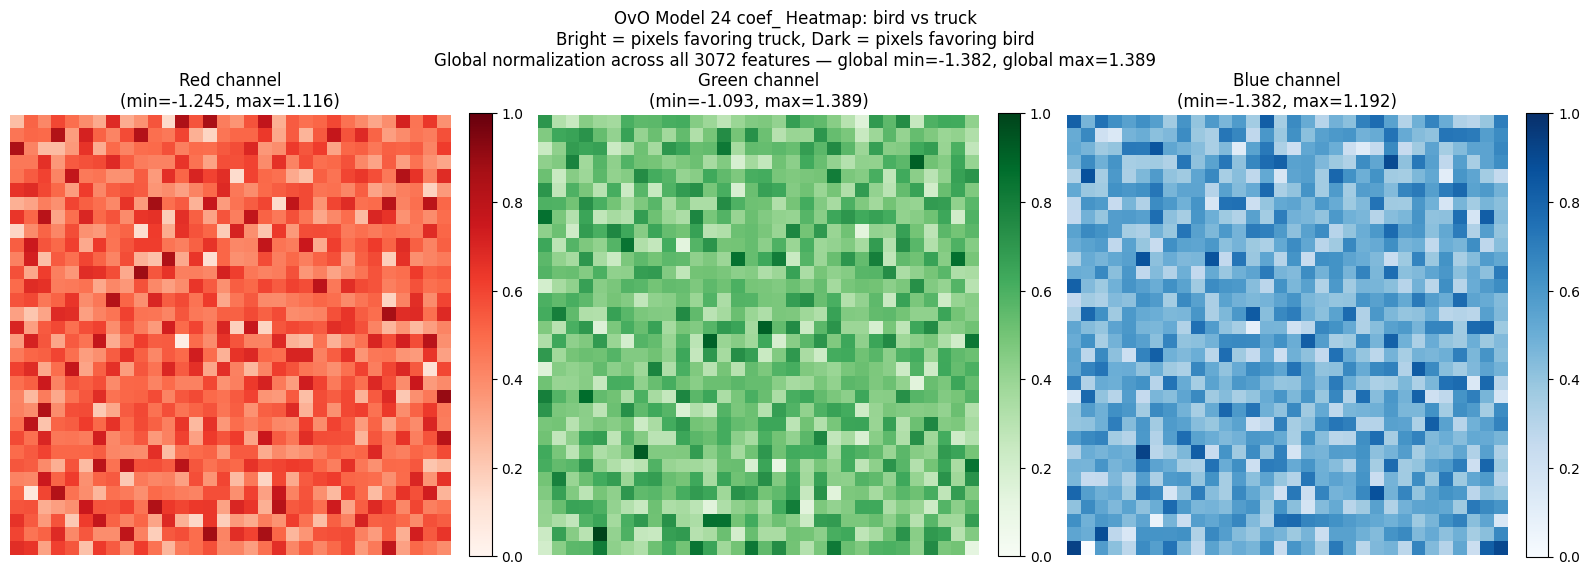

In [68]:
model_idx = 23

estimators = model_ovo.estimators_
estimator = estimators[model_idx]
label1 = class_pairs_names[model_idx][0]
label2 = class_pairs_names[model_idx][1]

coef = estimator.coef_[0]             # shape (3072,)
coef_image = coef.reshape(32, 32, 3)  # (32, 32, 3)

channel_names = ['Red', 'Green', 'Blue']
cmaps = ['Reds', 'Greens', 'Blues']

# Global normalization across all 3072 features
global_min = coef_image.min()
global_max = coef_image.max()

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

for ch in range(3):
    channel = coef_image[:, :, ch]
    channel_norm = (channel - global_min) / (global_max - global_min)

    im = axes[ch].imshow(channel_norm, cmap=cmaps[ch], vmin=0, vmax=1)
    axes[ch].set_title(f'{channel_names[ch]} channel\n'
                       f'(min={channel.min():.3f}, max={channel.max():.3f})')
    axes[ch].axis('off')
    plt.colorbar(im, ax=axes[ch], fraction=0.046, pad=0.04)

plt.suptitle(f'OvO Model {model_idx+1} coef_ Heatmap: {label1} vs {label2}\n'
             f'Bright = pixels favoring {label2}, Dark = pixels favoring {label1}\n'
             f'Global normalization across all 3072 features — '
             f'global min={global_min:.3f}, global max={global_max:.3f}',
             fontsize=12)
plt.tight_layout()
plt.show()

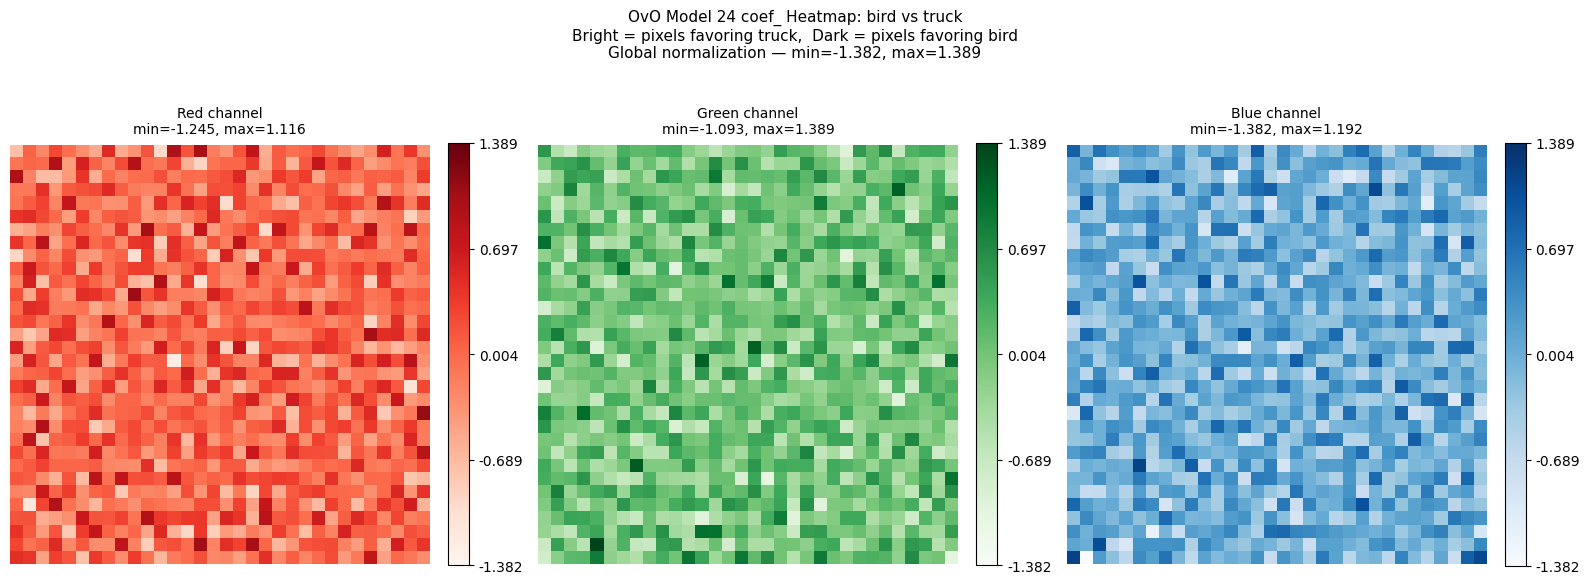

In [69]:
model_idx = 23

estimators = model_ovo.estimators_
estimator = estimators[model_idx]
label1 = class_pairs_names[model_idx][0]
label2 = class_pairs_names[model_idx][1]

coef = estimator.coef_[0]
coef_image = coef.reshape(32, 32, 3)

channel_names = ['Red', 'Green', 'Blue']
cmaps = ['Reds', 'Greens', 'Blues']

global_min = coef_image.min()
global_max = coef_image.max()

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

for ch in range(3):
    channel = coef_image[:, :, ch]
    channel_norm = (channel - global_min) / (global_max - global_min)

    im = axes[ch].imshow(channel_norm, cmap=cmaps[ch], vmin=0, vmax=1)
    axes[ch].set_title(f'{channel_names[ch]} channel\n'
                       f'min={channel.min():.3f}, max={channel.max():.3f}',
                       fontsize=10, pad=8)
    axes[ch].axis('off')

    # Colorbar ticks reflect actual weight values not normalized values
    cbar = plt.colorbar(im, ax=axes[ch], fraction=0.046, pad=0.04)
    cbar.set_ticks([0, 0.25, 0.5, 0.75, 1.0])
    cbar.set_ticklabels([f'{global_min:.3f}',
                         f'{global_min + 0.25*(global_max-global_min):.3f}',
                         f'{global_min + 0.50*(global_max-global_min):.3f}',
                         f'{global_min + 0.75*(global_max-global_min):.3f}',
                         f'{global_max:.3f}'])

plt.suptitle(f'OvO Model {model_idx+1} coef_ Heatmap: {label1} vs {label2}\n'
             f'Bright = pixels favoring {label2},  Dark = pixels favoring {label1}\n'
             f'Global normalization — min={global_min:.3f}, max={global_max:.3f}',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

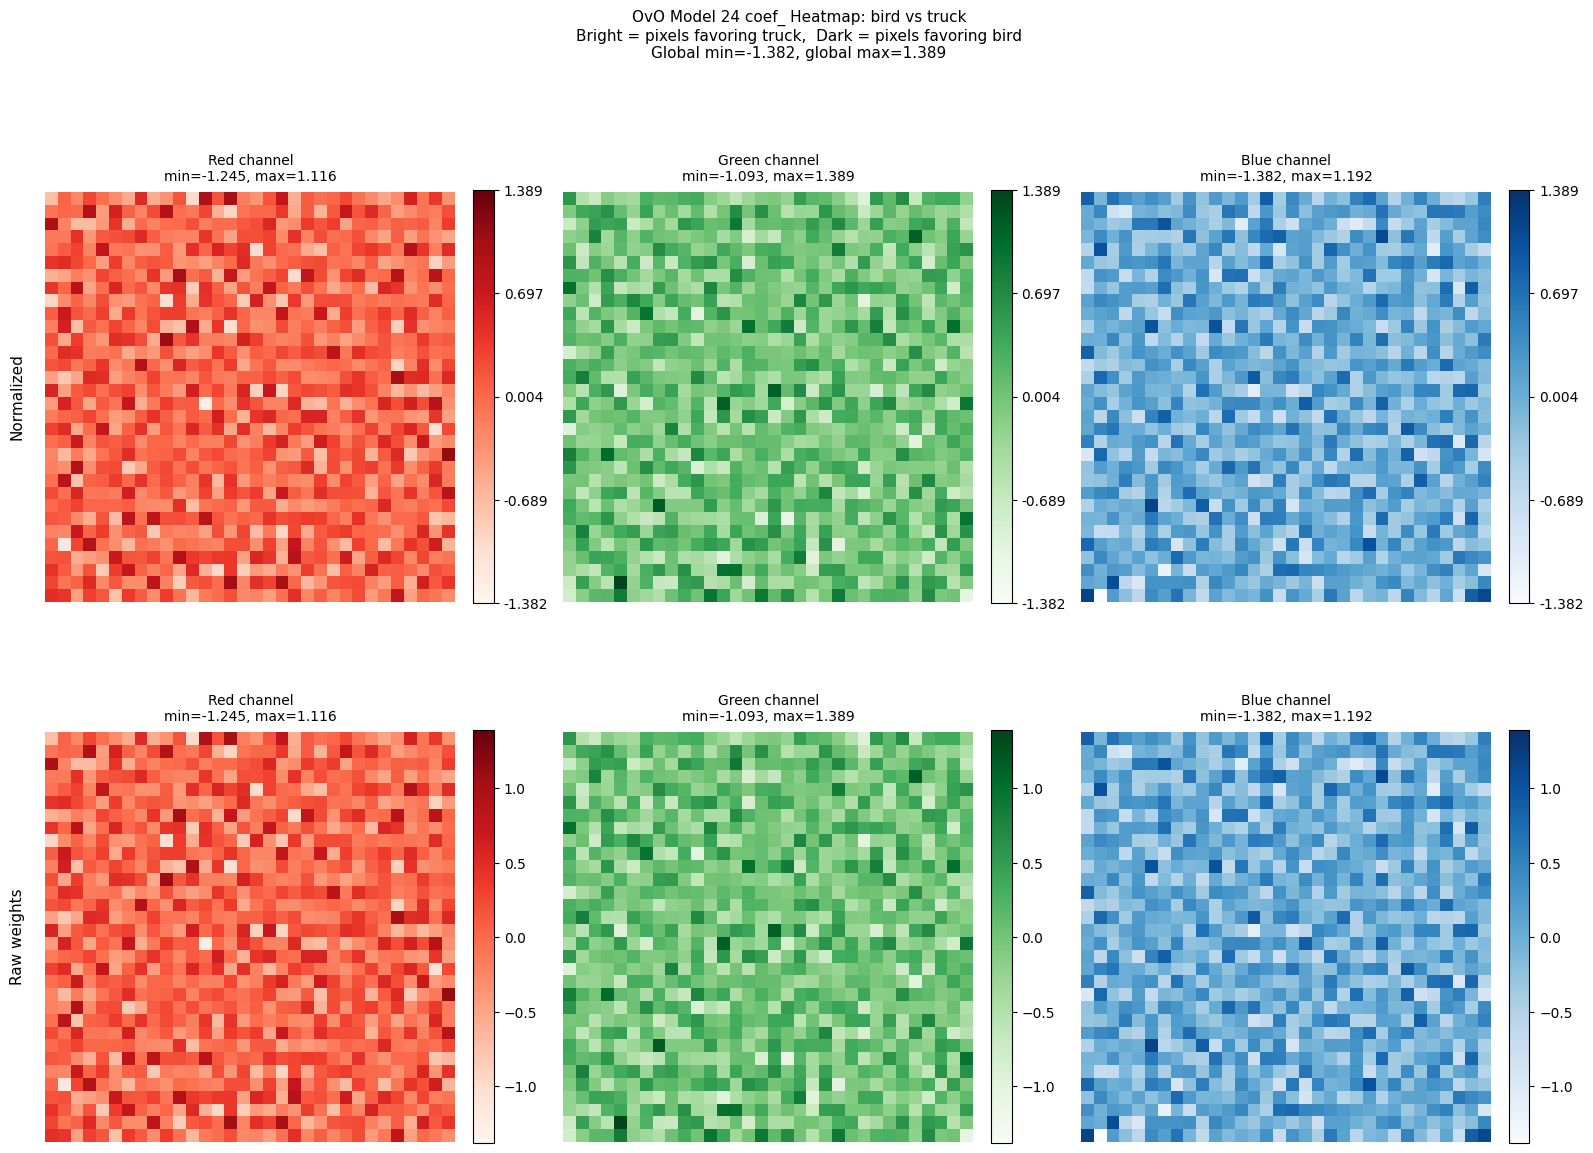

In [70]:
model_idx = 23

estimators = model_ovo.estimators_
estimator = estimators[model_idx]
label1 = class_pairs_names[model_idx][0]
label2 = class_pairs_names[model_idx][1]

coef = estimator.coef_[0]
coef_image = coef.reshape(32, 32, 3)

channel_names = ['Red', 'Green', 'Blue']
cmaps = ['Reds', 'Greens', 'Blues']

global_min = coef_image.min()
global_max = coef_image.max()

fig, axes = plt.subplots(2, 3, figsize=(16, 12))

# --- Row 1: globally normalized ---
for ch in range(3):
    channel = coef_image[:, :, ch]
    channel_norm = (channel - global_min) / (global_max - global_min)

    im = axes[0, ch].imshow(channel_norm, cmap=cmaps[ch], vmin=0, vmax=1)
    axes[0, ch].set_title(f'{channel_names[ch]} channel\n'
                          f'min={channel.min():.3f}, max={channel.max():.3f}',
                          fontsize=10, pad=8)
    axes[0, ch].axis('off')

    cbar = plt.colorbar(im, ax=axes[0, ch], fraction=0.046, pad=0.04)
    cbar.set_ticks([0, 0.25, 0.5, 0.75, 1.0])
    cbar.set_ticklabels([f'{global_min:.3f}',
                         f'{global_min + 0.25*(global_max-global_min):.3f}',
                         f'{global_min + 0.50*(global_max-global_min):.3f}',
                         f'{global_min + 0.75*(global_max-global_min):.3f}',
                         f'{global_max:.3f}'])

# --- Row 2: no normalization ---
for ch in range(3):
    channel = coef_image[:, :, ch]

    im = axes[1, ch].imshow(channel, cmap=cmaps[ch],
                             vmin=global_min, vmax=global_max)
    axes[1, ch].set_title(f'{channel_names[ch]} channel\n'
                           f'min={channel.min():.3f}, max={channel.max():.3f}',
                           fontsize=10, pad=8)
    axes[1, ch].axis('off')
    plt.colorbar(im, ax=axes[1, ch], fraction=0.046, pad=0.04)

# Row labels
axes[0, 0].annotate('Normalized', xy=(-0.05, 0.5),
                    xycoords='axes fraction', fontsize=11,
                    ha='right', va='center', rotation=90)
axes[1, 0].annotate('Raw weights', xy=(-0.05, 0.5),
                    xycoords='axes fraction', fontsize=11,
                    ha='right', va='center', rotation=90)

plt.suptitle(f'OvO Model {model_idx+1} coef_ Heatmap: {label1} vs {label2}\n'
             f'Bright = pixels favoring {label2},  Dark = pixels favoring {label1}\n'
             f'Global min={global_min:.3f}, global max={global_max:.3f}',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

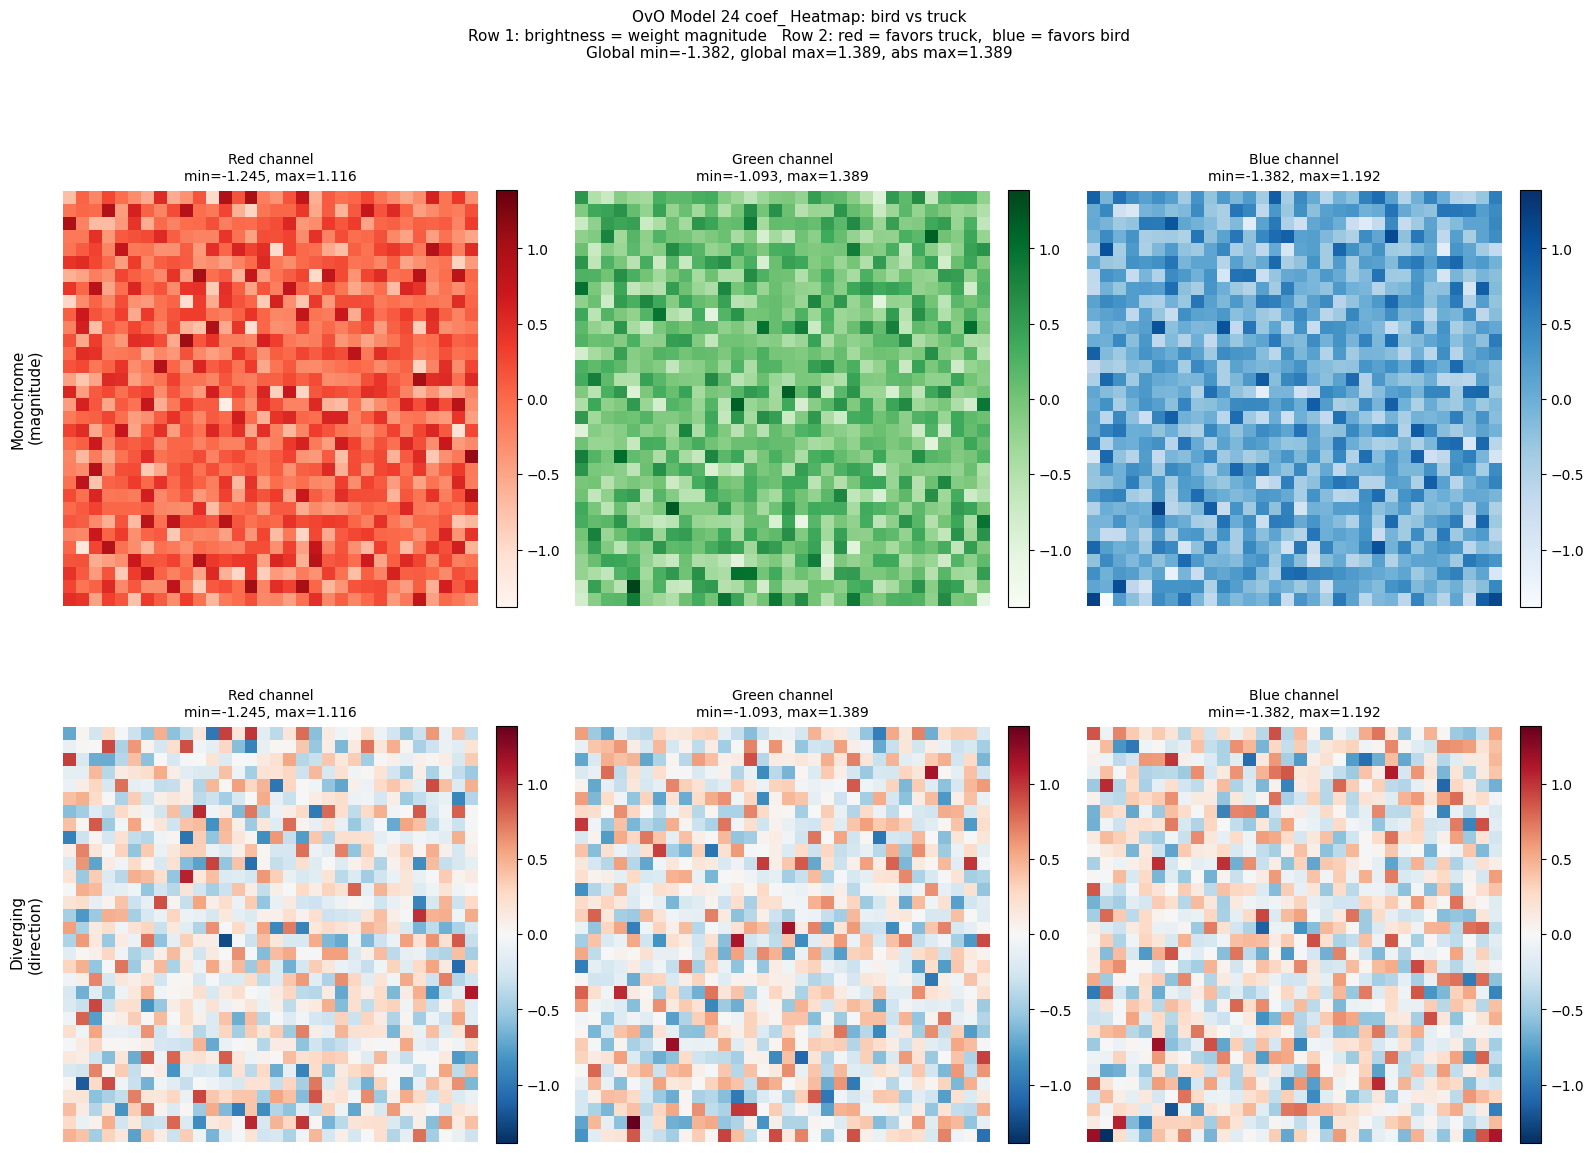

In [72]:
model_idx = 23

estimators = model_ovo.estimators_
estimator = estimators[model_idx]
label1 = class_pairs_names[model_idx][0]
label2 = class_pairs_names[model_idx][1]

coef = estimator.coef_[0]
coef_image = coef.reshape(32, 32, 3)

channel_names = ['Red', 'Green', 'Blue']
cmaps = ['Reds', 'Greens', 'Blues']

global_min = coef_image.min()
global_max = coef_image.max()
abs_max = np.abs(coef_image).max()  # for symmetric diverging scale

fig, axes = plt.subplots(2, 3, figsize=(16, 12))

# --- Row 1: monochrome per channel ---
for ch in range(3):
    channel = coef_image[:, :, ch]
    im = axes[0, ch].imshow(channel, cmap=cmaps[ch],
                             vmin=global_min, vmax=global_max)
    axes[0, ch].set_title(f'{channel_names[ch]} channel\n'
                           f'min={channel.min():.3f}, max={channel.max():.3f}',
                           fontsize=10, pad=8)
    axes[0, ch].axis('off')
    plt.colorbar(im, ax=axes[0, ch], fraction=0.046, pad=0.04)

# --- Row 2: diverging colormap ---
for ch in range(3):
    channel = coef_image[:, :, ch]
    im = axes[1, ch].imshow(channel, cmap='RdBu_r',
                             vmin=-abs_max, vmax=abs_max)
    axes[1, ch].set_title(f'{channel_names[ch]} channel\n'
                           f'min={channel.min():.3f}, max={channel.max():.3f}',
                           fontsize=10, pad=8)
    axes[1, ch].axis('off')
    plt.colorbar(im, ax=axes[1, ch], fraction=0.046, pad=0.04)

# Row labels
axes[0, 0].annotate('Monochrome\n(magnitude)',
                    xy=(-0.05, 0.5), xycoords='axes fraction',
                    fontsize=11, ha='right', va='center', rotation=90)
axes[1, 0].annotate('Diverging\n(direction)',
                    xy=(-0.05, 0.5), xycoords='axes fraction',
                    fontsize=11, ha='right', va='center', rotation=90)

plt.suptitle(f'OvO Model {model_idx+1} coef_ Heatmap: {label1} vs {label2}\n'
             f'Row 1: brightness = weight magnitude   '
             f'Row 2: red = favors {label2},  blue = favors {label1}\n'
             f'Global min={global_min:.3f}, global max={global_max:.3f}, '
             f'abs max={abs_max:.3f}',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

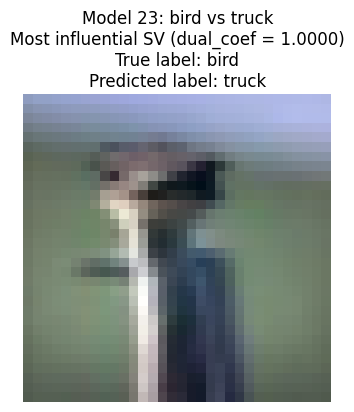

In [65]:
estimator = estimators[model_idx]
dual_coefs = np.abs(estimator.dual_coef_[0])

# Index of the support vector with the largest dual coefficient
max_idx = np.argmax(dual_coefs)

# Get first key matching target_value, return None if not found
index1 = next((k for k, v in label_codes.items() if v == label1), None)
index2 = next((k for k, v in label_codes.items() if v == label2), None)

# Retrieve the true label of the support vector
global_mask = np.where((train_labels == index1) | (train_labels == index2))[0]
local_sv_indices = estimator.support_        # local indices within binary subset
global_sv_index = global_mask[local_sv_indices[max_idx]]  # map to global
true_label = train_labels[global_sv_index]

# Get the model's predicted label
decision_score = estimator.decision_function(max_sv_image.reshape(1, -1))[0]
predicted_class = index2 if decision_score > 0 else index1
predicted_label = label_codes.get(predicted_class)

# Retrieve the actual image
max_sv_image = estimator.support_vectors_[max_idx].reshape(32, 32, 3)

# Normalize for display if your pixels are not already in [0,1]
max_sv_image_norm = (max_sv_image - max_sv_image.min()) / (max_sv_image.max() - max_sv_image.min())

plt.figure(figsize=(4, 4))
plt.imshow(max_sv_image_norm)
plt.axis('off')
plt.title(f'Model {model_idx}: {label1} vs {label2}\n'
          f'Most influential SV (dual_coef = {dual_coefs[max_idx]:.4f})\n'
          f'True label: {label_codes.get(true_label)}\n'
          f'Predicted label: {predicted_label}')
plt.show()

In [66]:
# decision_function gives the signed distance from the boundary scaled by the margin
score = estimator.decision_function(max_sv_image.reshape(1, -1))[0]

# y_i is +1 or -1 depending on which class this SV belongs to
y_i = 1.0 if true_label == index2 else -1.0

# slack variable: xi = max(0, 1 - y_i * score)
xi = max(0, 1 - y_i * score)

print(f'Decision score:  {score:.4f}')
print(f'y_i:             {y_i}')
print(f'Slack (xi):      {xi:.4f}')

if xi == 0:
    print('Outside margin, correctly classified, no penalty')
elif 0 < xi <= 1:
    print('Inside margin but correctly classified (lambda = C)')
else:
    print(f'Misclassified (xi > 1, lambda = C)')

Decision score:  1.2994
y_i:             -1.0
Slack (xi):      2.2994
Misclassified (xi > 1, lambda = C)


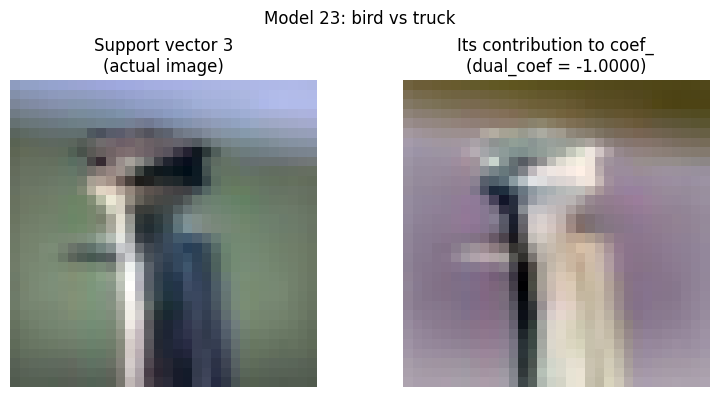

In [ ]:
estimator = estimators[model_idx]
dual_coefs = estimator.dual_coef_[0]

# Pick whichever SV you want — e.g. the most influential
sv_idx = np.argmax(np.abs(dual_coefs))

# Contribution = dual_coef * pixel_vector
contribution = dual_coefs[sv_idx] * estimator.support_vectors_[sv_idx]
contribution_image = contribution.reshape(32, 32, 3)
contribution_norm = (contribution_image - contribution_image.min()) / (contribution_image.max() - contribution_image.min())

# The raw SV image for comparison
sv_image = estimator.support_vectors_[sv_idx].reshape(32, 32, 3)
sv_image_norm = (sv_image - sv_image.min()) / (sv_image.max() - sv_image.min())

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(sv_image_norm)
axes[0].set_title(f'Support vector {sv_idx}\n(actual image)')
axes[0].axis('off')

axes[1].imshow(contribution_norm)
axes[1].set_title(f'Its contribution to coef_\n(dual_coef = {dual_coefs[sv_idx]:.4f})')
axes[1].axis('off')

plt.suptitle(f'OvO SVM Model {model_idx}: {label1} vs {label2}')
plt.tight_layout()
plt.show()

In [64]:
estimator = estimators[model_idx]
dual_coefs = estimator.dual_coef_[0]

n_pos = (dual_coefs == 1.0).sum()
n_neg = (dual_coefs == -1.0).sum()
n_bounded = n_pos + n_neg
n_total = len(dual_coefs)
pct_bounded = n_bounded / n_total * 100

print(f'Total SVs:           {n_total}')
print(f'Bounded at +1:       {n_pos}')
print(f'Bounded at -1:       {n_neg}')
print(f'Total bounded (±1):  {n_bounded}')
print(f'Percentage bounded:  {pct_bounded:.1f}%')

Total SVs:           2995
Bounded at +1:       436
Bounded at -1:       517
Total bounded (±1):  953
Percentage bounded:  31.8%


In [ ]:
model_ovr = unpickle('model_ovr.pkl')


c:\Users\tdefu\Downloads\vscode_CS_6140\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator SVC from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\tdefu\Downloads\vscode_CS_6140\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LabelBinarizer from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\tdefu\Downloads\vscode_CS_6140\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator OneVsRestClassifier from version 1.

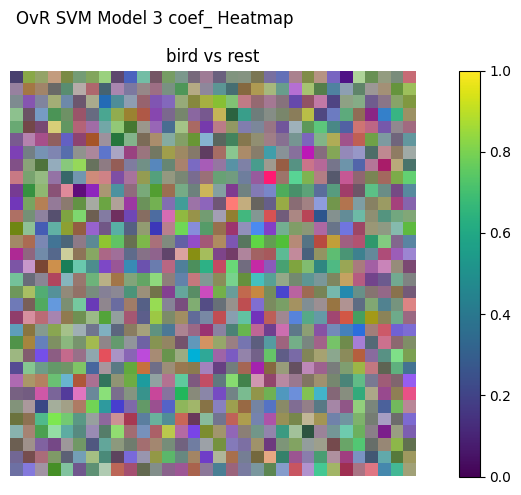

In [61]:
#fig, axes = plt.subplots(2, 5, figsize=(18, 8))
plt.figure(figsize=(9, 5))

model_idx = 2
estimator = model_ovr.estimators_[model_idx]
label = model_ovr.classes_[model_idx]

coef_image = estimator.coef_[0].reshape(32, 32, 3)
coef_norm = (coef_image - coef_image.min()) / (coef_image.max() - coef_image.min())

plt.imshow(coef_norm)
plt.axis('off')
plt.title(f'{label_codes.get(label)} vs rest')
plt.colorbar()

plt.suptitle(f'OvR SVM Model {model_idx+1} coef_ Heatmap')
plt.tight_layout()
plt.show()

90


NameError: name 'train_labels' is not defined

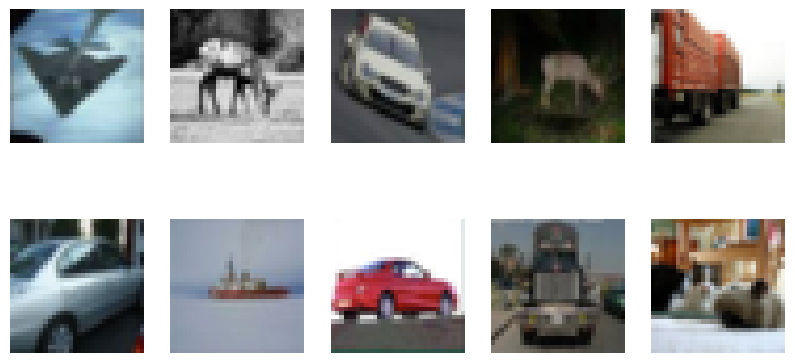

In [ ]:
overall_class_dist_dfs = []
sv_class_dist_dfs = []
model_idx = 0
class_idx = 0
print(len(sv_im_lists))
for j in range(len(sv_im_lists)): # a different list of sv_images for each class in each model.
    plt.figure(figsize=(10,5))
    image_bank = copy.deepcopy(sv_im_lists[j].tolist())
    for i in range(min(10, len(sv_im_lists[j]))):
        plt.subplot(2,5,i+1)
        plt.imshow(image_bank.pop(random.randint(0, len(image_bank)-1)))
        plt.axis('off')
    df = pd.DataFrame(train_labels, columns=['labels'])
    df['support_vectors'] = 1 # default value, will stay where condition is true
    # reset value to 0 where "where" condition is false
    df['support_vectors'] = df['support_vectors'].where(df['support_vectors'].index.isin(sv_idx_lists[j]), 0)
    overall_class_dist_dfs.append(df)
    df['text_labels'] = df['labels'].map(label_codes)
    print(df.columns)
    temp_df = df[df['support_vectors'] == 1]
    sv_class_dist_dfs.append(temp_df)
    print(temp_df.head())

    # Check that the support_vectors one hot column worked
    # print(df['support_vectors'][0:20])
    # print(sv_indices_list[j][0:20])
    if ((class_idx+1) % 2):
        model_name = class_pairs_list.pop()
    class_name = model_name[class_idx]
    class_idx = (class_idx + 1) % 2
    try: 
        print(f'{len(class_pairs_list)} {len(class_pairs_list[model_idx])}')
        plt.suptitle(f"Sample Support Vectors (OvO) for Model {model_name} Class {class_name}")
    except IndexError:
        print(f"list index out of range for model_idx: {model_idx}, class_idx: {class_idx}")
    plt.show()
